###Projeto: Classificação de Grãos de Trigo (Seeds Dataset)
###Em cooperativas agrícolas menores, a classificação dos grãos é feita de forma manual sujeito a demora e a erros humanos. O objetivo deste exercício é aplicar a metodologia CRISP-DM para desenvolver um modelo de aprendizado de máquina que classifique variedades de grãos de trigo com base em suas características físicas. O conjunto de dados contém medições de 210 amostras de grãos de trigo pertencentes a três variedades diferentes:Kama, Rosa e a Canadian.

#### Análise e pré-processamento dos dados fornecidos


In [1]:
# Arquivo Seeds_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. Nomeação das colunas
nomes_colunas = [
    'Area', 'Perimetro', 'Compacidade', 'Comprimento_Grao',
    'Largura_Grao', 'Assimetria', 'Comprimento_Sulco', 'Classe'
]

# 2. Carregar o arquivo
df = pd.read_csv(
    'seeds_dataset.csv',
    sep=r'\s+',          # Trata múltiplos espaços ou tabulações (\t) como separadores
    names=nomes_colunas, # Define os nomes reais das colunas
    header=None          # Impede que a primeira linha de dados vire cabeçalho
)

df.head()
# Nomes científicos das sementes
mapeamento_classes = {
    1: 'Kama',
    2: 'Rosa',
    3: 'Canadian'
}

df['Classe'] = df['Classe'].map(mapeamento_classes)

# Exibe para conferir se deu certo
df.head()

# Informações gerais sobre colunas e tipos de dados
print("--- Estrutura dos Dados ---")
df.info()


--- Estrutura dos Dados ---
<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               210 non-null    float64
 1   Perimetro          210 non-null    float64
 2   Compacidade        210 non-null    float64
 3   Comprimento_Grao   210 non-null    float64
 4   Largura_Grao       210 non-null    float64
 5   Assimetria         210 non-null    float64
 6   Comprimento_Sulco  210 non-null    float64
 7   Classe             210 non-null    str    
dtypes: float64(7), str(1)
memory usage: 14.4 KB


#### Estatísticas descritivas


In [2]:
# Média, Mediana/50%, Desvio Padrão/std
print("\n--- Estatísticas Descritivas ---")
df.describe(include='all').T


--- Estatísticas Descritivas ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Area,210.0,NaN,NaN,NaN,14.847524,2.909699,10.59,12.27,14.355,17.305,21.18
Perimetro,210.0,NaN,NaN,NaN,14.559286,1.305959,12.41,13.45,14.32,15.715,17.25
Compacidade,210.0,NaN,NaN,NaN,0.870999,0.023629,0.8081,0.8569,0.87345,0.887775,0.9183
Comprimento_Grao,210.0,NaN,NaN,NaN,5.628533,0.443063,4.899,5.26225,5.5235,5.97975,6.675
Largura_Grao,210.0,NaN,NaN,NaN,3.258605,0.377714,2.63,2.944,3.237,3.56175,4.033
Assimetria,210.0,NaN,NaN,NaN,3.700201,1.503557,0.7651,2.5615,3.599,4.76875,8.456
Comprimento_Sulco,210.0,NaN,NaN,NaN,5.408071,0.49148,4.519,5.045,5.223,5.877,6.55
Classe,210,3,Kama,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Visualização dos Gráficos


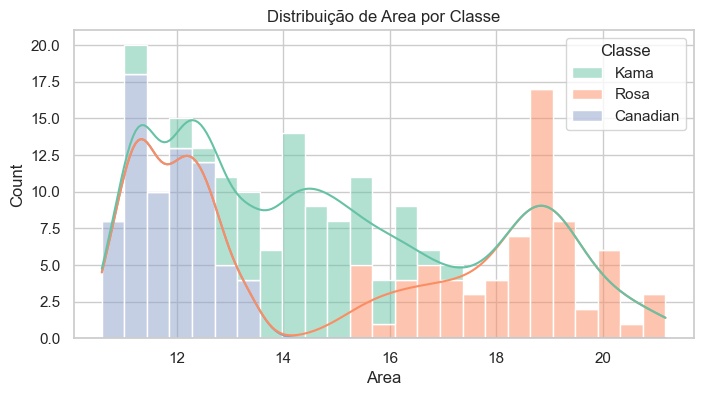

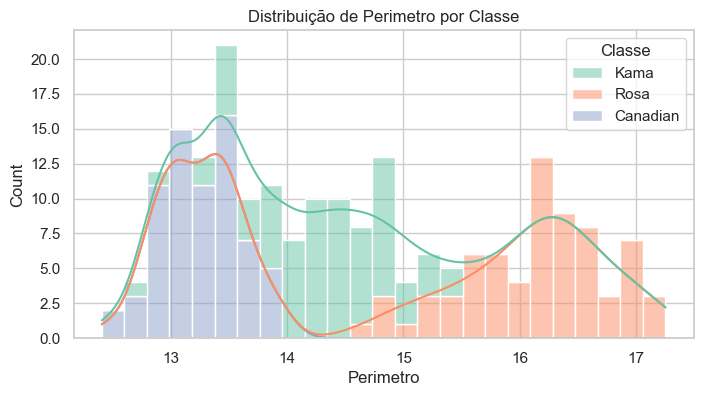

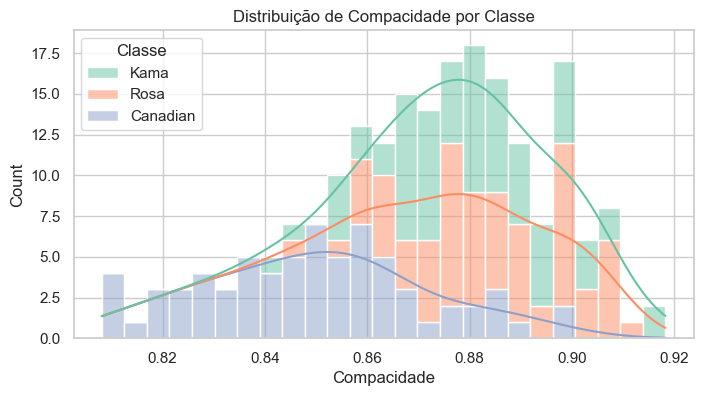

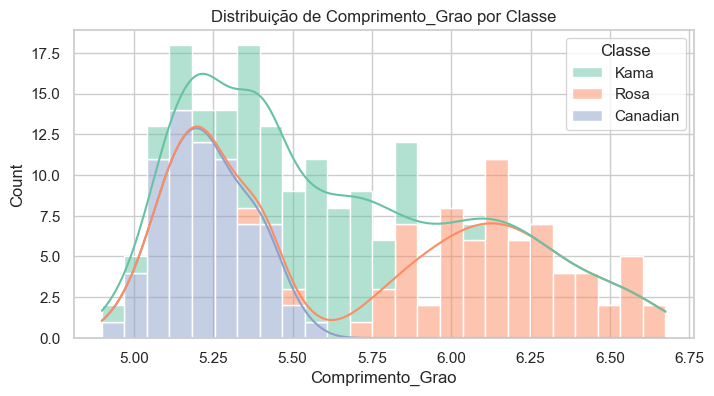

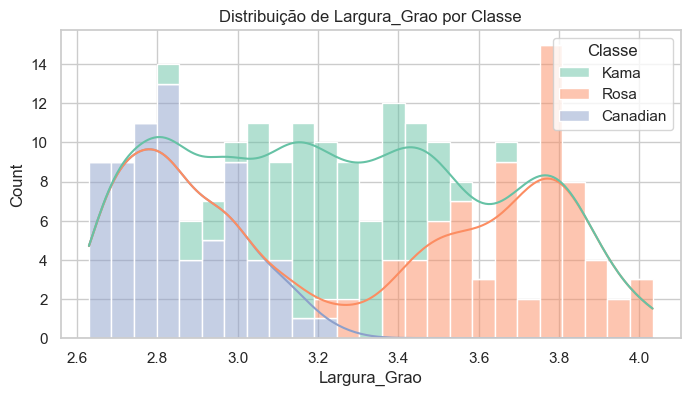

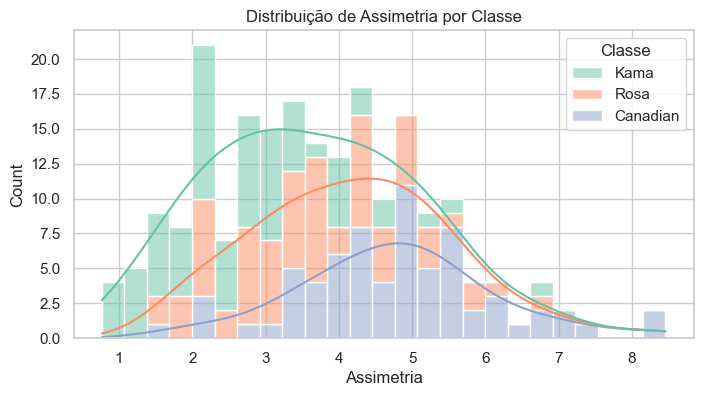

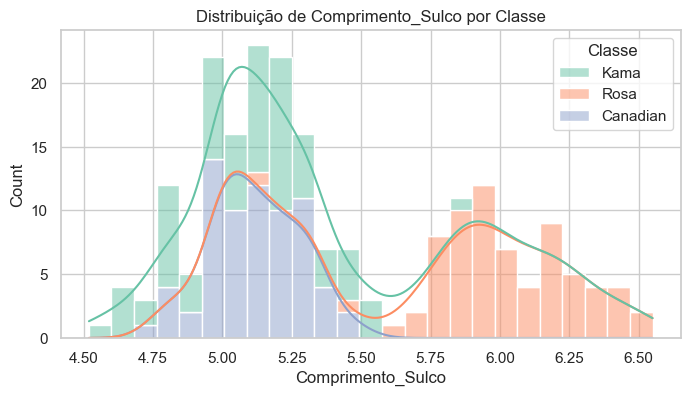

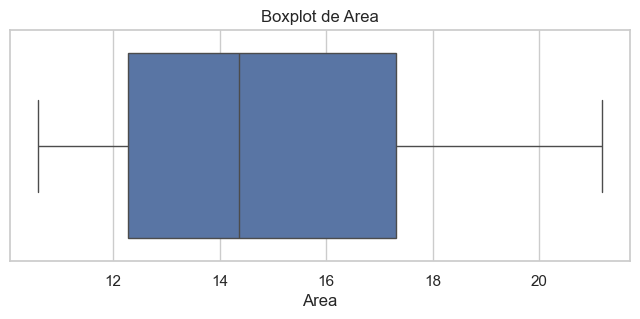

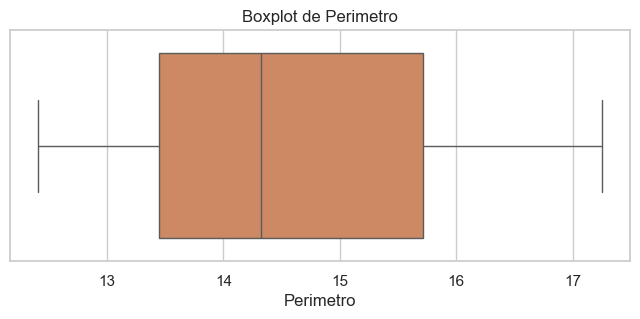

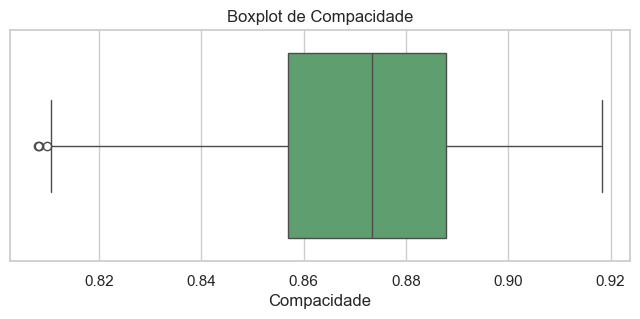

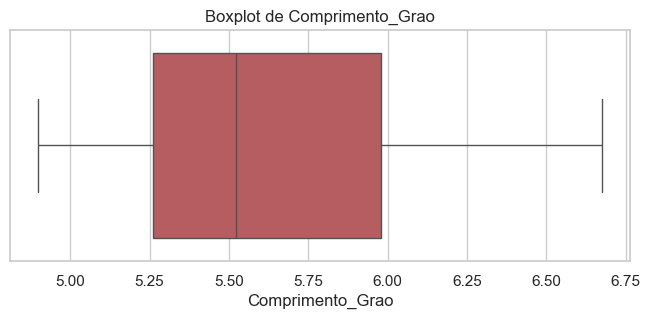

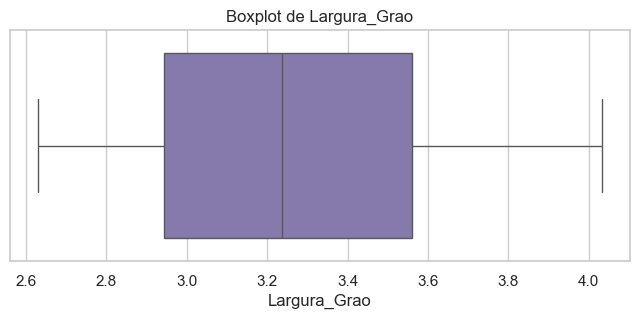

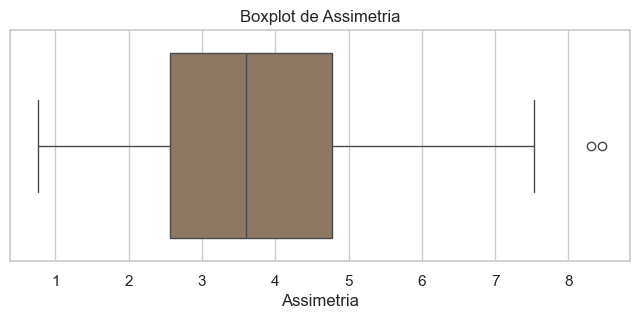

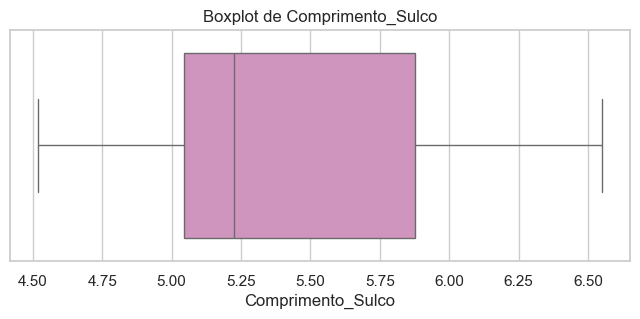

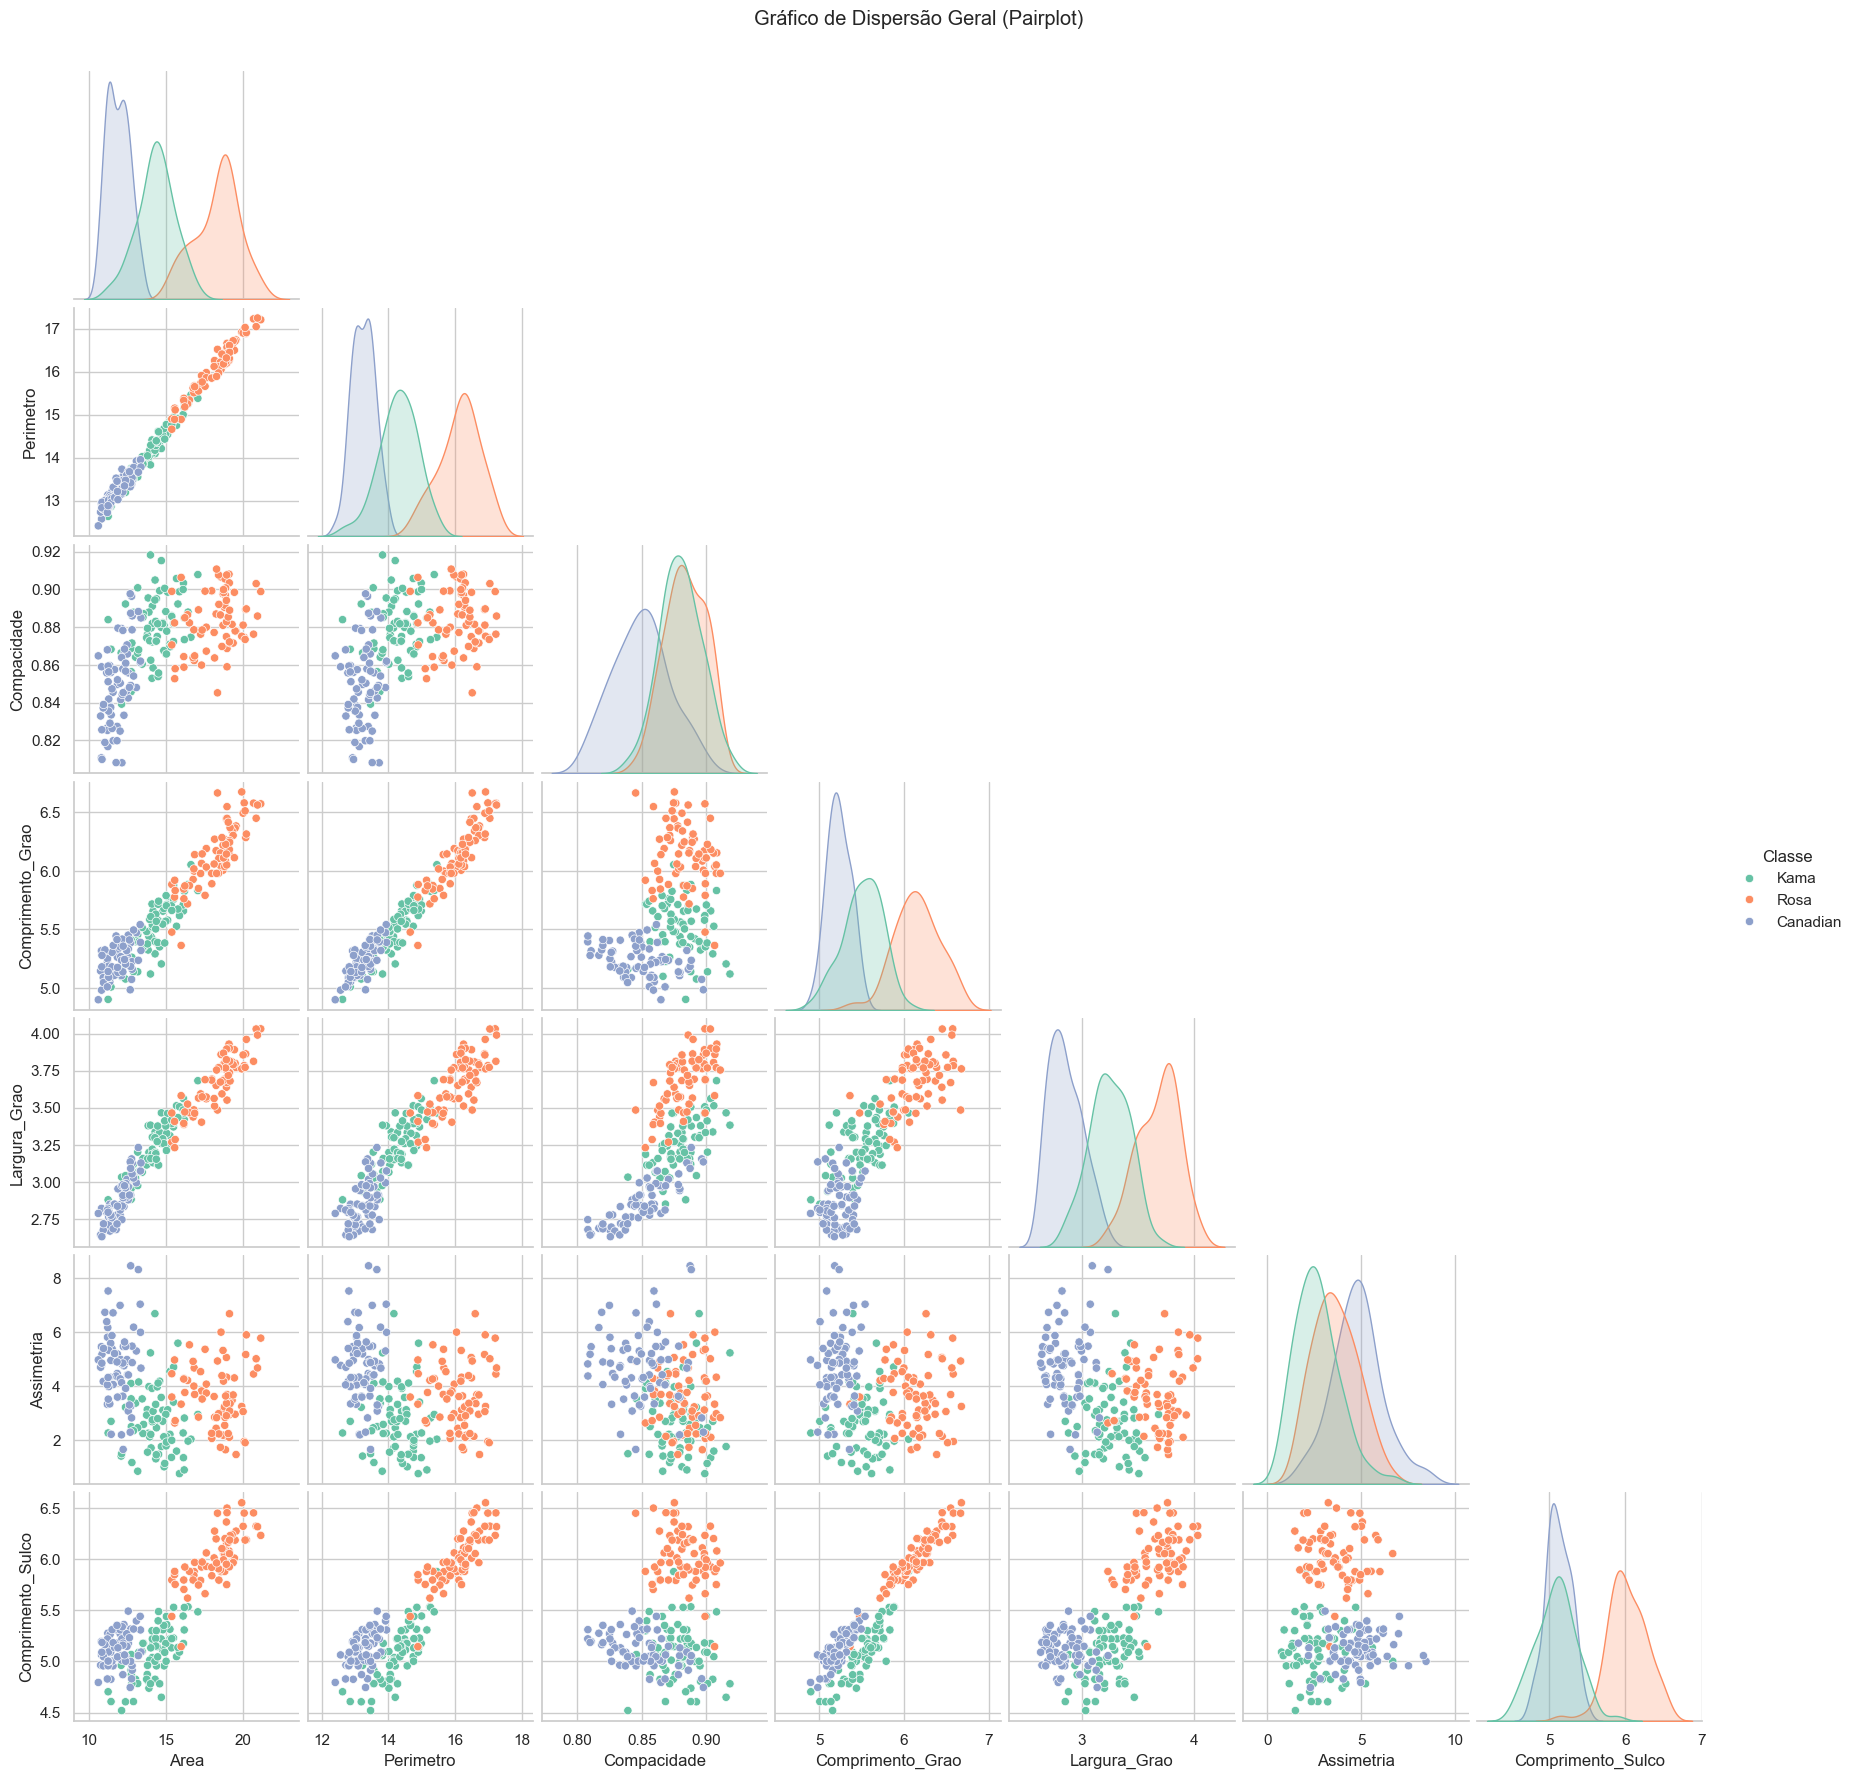

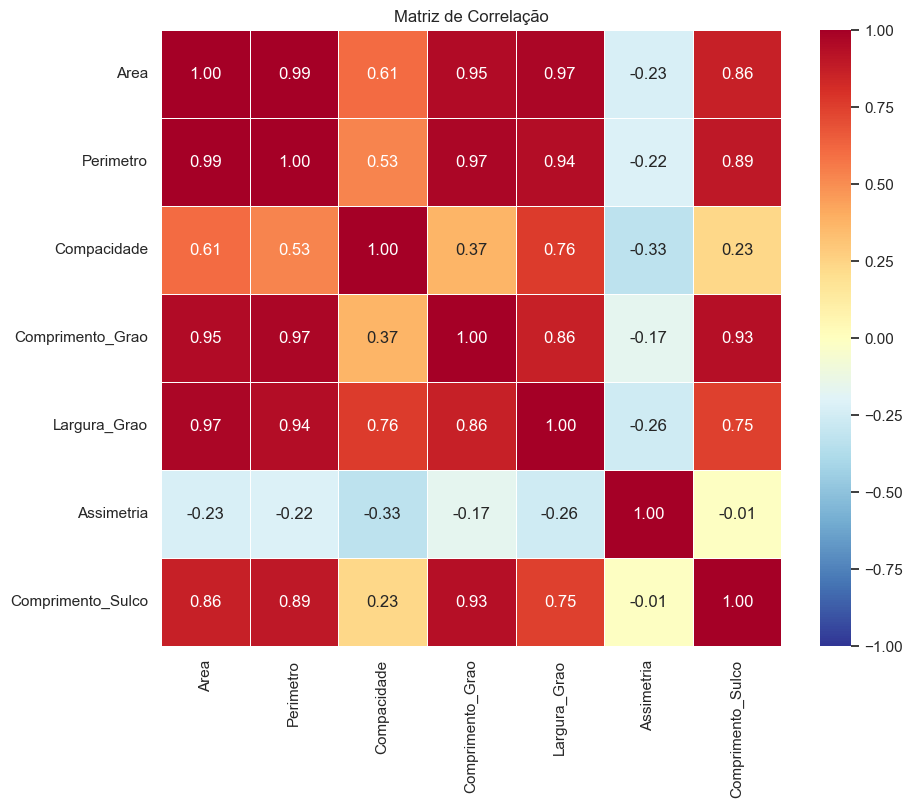

In [50]:
#  Gráficos de Histograma, Boxplot, Dispersão e Matriz de correlação
sns.set_theme(style="whitegrid")

# Filtrar colunas numéricas (removendo a 'Classe' para os loops de recursos)
num_cols = df.select_dtypes(include=[np.number]).columns
features = [col for col in num_cols if col != 'Classe']

# --- Histogramas (Coloridos por Classe de grão) ---
for col in features:
    plt.figure(figsize=(8, 4))
    # 'hue' separa as cores pelos tipos de semente usando a paleta 'Set2'
    sns.histplot(data=df, x=col, hue='Classe', kde=True, bins=25, palette='Set2', multiple='stack')
    plt.title(f'Distribuição de {col} por Classe')
    plt.show()

# --- Boxplots (Cada característica com uma cor viva diferente) ---

cores = sns.color_palette("deep", len(features))

for i, col in enumerate(features):
    plt.figure(figsize=(8, 3))
    # 'color' define a cor específica deste boxplot
    sns.boxplot(x=df[col], color=cores[i])
    plt.title(f'Boxplot de {col}')
    plt.show()

# --- Gráfico de Dispersão Geral (Pair plot colorido) ---
sns.pairplot(df, hue='Classe', palette='Set2', corner=True)
plt.suptitle('Gráfico de Dispersão Geral (Pairplot)', y=1.02)
plt.show()

# --- Matriz de Correlação  ---
plt.figure(figsize=(10, 8))
# Usamos 'RdYlBu_r' que vai do azul escuro (negativo) ao vermelho escuro (positivo)
sns.heatmap(df[num_cols].corr(), annot=True, cmap='RdYlBu_r', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlação')
plt.show()


#### Identificação dos valores ausentes

In [51]:
#  Checagem
print("Valores ausentes por coluna:")
print(df.isnull().sum())

# Tratamento básico: preenchimento com a mediana
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())


Valores ausentes por coluna:
Area                 0
Perimetro            0
Compacidade          0
Comprimento_Grao     0
Largura_Grao         0
Assimetria           0
Comprimento_Sulco    0
Classe               0
dtype: int64


#### Padronização das características


In [52]:
# Média = 0, Desvio Padrão = 1
from sklearn.preprocessing import StandardScaler

# 1. Isolando as características numéricas para aplicar a padronização
colunas_numericas = df.drop(columns=['Classe']).columns
scaler = StandardScaler()
df_processado = df.copy()
df_processado[colunas_numericas] = scaler.fit_transform(df[colunas_numericas])
print("--- DataFrame Único com Dados Padronizados e Classe Integrada ---")
df_processado.head()


--- DataFrame Único com Dados Padronizados e Classe Integrada ---


,Area,Perimetro,Compacidade,Comprimento_Grao,Largura_Grao,Assimetria,Comprimento_Sulco,Classe
0,0.142098,0.215462,0.000061,0.304218,0.141702,-0.986152,-0.383577,Kama
1,0.011188,0.008224,0.428515,-0.168625,0.197432,-1.788166,-0.922013,Kama
2,-0.192067,-0.360201,1.442383,-0.763637,0.208048,-0.667479,-1.189192,Kama
3,-0.347091,-0.475333,1.039381,-0.688978,0.319508,-0.960818,-1.229983,Kama
4,0.445257,0.330595,1.374509,0.066666,0.805159,-1.563495,-0.475356,Kama


#### Implementação e comparação dos diferentes algoritmos de classificação


In [53]:
# Algoritmos de classificação
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



#### Divisão em treino e teste


In [54]:
# Divisão
# ==========================================
X = df_processado.drop(columns=['Classe'])
y = df_processado['Classe']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Dados de Treinamento: {X_train.shape[0]} amostras")
print(f"Dados de Teste: {X_test.shape[0]} amostras\n")

Dados de Treinamento: 147 amostras
Dados de Teste: 63 amostras



#### Definição dos Modelos


In [55]:
# KNN, SVM e Random Forest
modelos = {
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(n_neighbors=5),
    "Support Vector Machine (SVM)": SVC(kernel='rbf', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Dicionário para armazenar a acurácia de cada um para comparação posterior
resultados_acuracia = {}


#### Treinamento, predição e avaliação


=== Treinando o modelo: K-Nearest Neighbors (KNN) ===
Acurácia Geral: 0.8889

Relatório de Classificação detalhado:
              precision    recall  f1-score   support

    Canadian       0.86      0.90      0.88        21
        Kama       0.85      0.81      0.83        21
        Rosa       0.95      0.95      0.95        21

    accuracy                           0.89        63
   macro avg       0.89      0.89      0.89        63
weighted avg       0.89      0.89      0.89        63



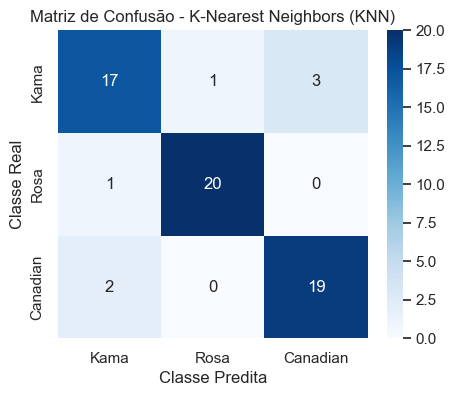

------------------------------------------------------------

=== Treinando o modelo: Support Vector Machine (SVM) ===
Acurácia Geral: 0.8889

Relatório de Classificação detalhado:
              precision    recall  f1-score   support

    Canadian       0.86      0.90      0.88        21
        Kama       0.85      0.81      0.83        21
        Rosa       0.95      0.95      0.95        21

    accuracy                           0.89        63
   macro avg       0.89      0.89      0.89        63
weighted avg       0.89      0.89      0.89        63



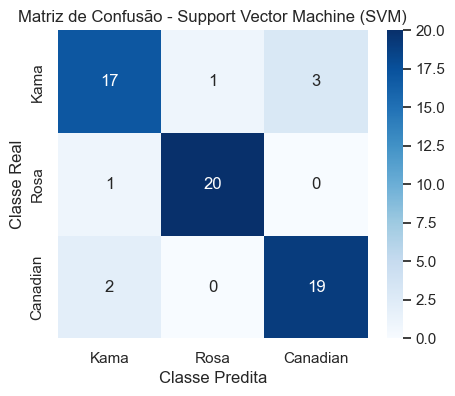

------------------------------------------------------------

=== Treinando o modelo: Random Forest ===
Acurácia Geral: 0.8413

Relatório de Classificação detalhado:
              precision    recall  f1-score   support

    Canadian       0.78      0.86      0.82        21
        Kama       0.79      0.71      0.75        21
        Rosa       0.95      0.95      0.95        21

    accuracy                           0.84        63
   macro avg       0.84      0.84      0.84        63
weighted avg       0.84      0.84      0.84        63



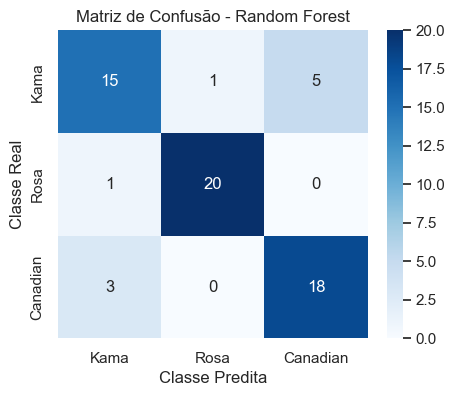

------------------------------------------------------------



In [56]:
# Acurácia, F-1, precisão, recall e support

for nome, modelo in modelos.items():
    print(f"=== Treinando o modelo: {nome} ===")
# Treinar o modelo
    modelo.fit(X_train, y_train)

    # Fazer predições no conjunto de teste
    y_pred = modelo.predict(X_test)

    # Calcular Acurácia Geral
    acuracia = accuracy_score(y_test, y_pred)
    resultados_acuracia[nome] = acuracia
    print(f"Acurácia Geral: {acuracia:.4f}")

    # Exibir Precisão, Recall e F1-Score por classe
    print("\nRelatório de Classificação detalhado:")
    print(classification_report(y_test, y_pred))

    # Gerar e Plotar Gráfico da Matriz de Confusão
    cm = confusion_matrix(y_test, y_pred, labels=['Kama', 'Rosa', 'Canadian'])

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Kama', 'Rosa', 'Canadian'],
                yticklabels=['Kama', 'Rosa', 'Canadian'])
    plt.title(f'Matriz de Confusão - {nome}')
    plt.ylabel('Classe Real')
    plt.xlabel('Classe Predita')
    plt.show()
    print("-" * 60 + "\n")

#### Comparação dos algoritmos

In [57]:
# Desempenho Final

print("=== COMPARAÇÃO FINAL DE DESEMPENHO ===")
for nome, acc in resultados_acuracia.items():
    print(f"-> {nome}: {acc * 100:.2f}% de Acurácia")

=== COMPARAÇÃO FINAL DE DESEMPENHO ===
-> K-Nearest Neighbors (KNN): 88.89% de Acurácia
-> Support Vector Machine (SVM): 88.89% de Acurácia
-> Random Forest: 84.13% de Acurácia


#### Otimização dos modelos para melhorar o desempenho


In [60]:
# 3. Otimização dos modelos para melhorar o desempenho

from sklearn.model_selection import GridSearchCV

print("=== INICIANDO A OTIMIZAÇÃO DE HIPERPARÂMETROS (GRID SEARCH) ===\n")

# ==========================================
# 3.1. DEFINIÇÃO DAS GRIDES DE PARÂMETROS
# ==========================================

# Parâmetros para testar no KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Parâmetros para testar no SVM
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}

# Parâmetros para testar o Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

# Dicionário unificando os modelos base e suas respectivas matrizes de parâmetros
config_otimizacao = {
    "K-Nearest Neighbors (KNN)": (KNeighborsClassifier(), param_grid_knn),
    "Support Vector Machine (SVM)": (SVC(random_state=42), param_grid_svm),
    "Random Forest": (RandomForestClassifier(random_state=42), param_grid_rf)
}

# Dicionário para guardar as novas acurácias dos modelos otimizados
resultados_otimizados = {}


=== INICIANDO A OTIMIZAÇÃO DE HIPERPARÂMETROS (GRID SEARCH) ===



#### Execução do GRID SEARCH e reavaliação


Otimizando K-Nearest Neighbors (KNN)...
-> Melhores parâmetros encontrados: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Nova Acurácia Geral: 0.8889

Novo Relatório de Classificação:
              precision    recall  f1-score   support

    Canadian       0.83      0.90      0.86        21
        Kama       0.85      0.81      0.83        21
        Rosa       1.00      0.95      0.98        21

    accuracy                           0.89        63
   macro avg       0.89      0.89      0.89        63
weighted avg       0.89      0.89      0.89        63



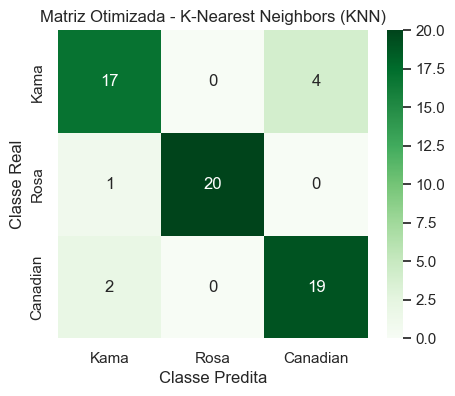

------------------------------------------------------------

Otimizando Support Vector Machine (SVM)...
-> Melhores parâmetros encontrados: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Nova Acurácia Geral: 0.8889

Novo Relatório de Classificação:
              precision    recall  f1-score   support

    Canadian       0.86      0.90      0.88        21
        Kama       0.85      0.81      0.83        21
        Rosa       0.95      0.95      0.95        21

    accuracy                           0.89        63
   macro avg       0.89      0.89      0.89        63
weighted avg       0.89      0.89      0.89        63



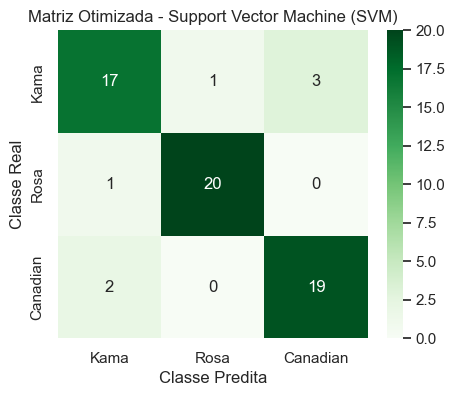

------------------------------------------------------------

Otimizando Random Forest...
-> Melhores parâmetros encontrados: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Nova Acurácia Geral: 0.8413

Novo Relatório de Classificação:
              precision    recall  f1-score   support

    Canadian       0.78      0.86      0.82        21
        Kama       0.79      0.71      0.75        21
        Rosa       0.95      0.95      0.95        21

    accuracy                           0.84        63
   macro avg       0.84      0.84      0.84        63
weighted avg       0.84      0.84      0.84        63



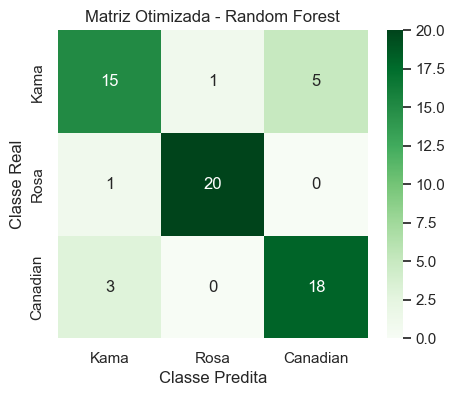

------------------------------------------------------------



In [61]:
# Execução
for nome, (modelo_base, grade) in config_otimizacao.items():
    print(f"Otimizando {nome}...")

    # Configurando o Grid Search com validação cruzada de 5 dobras (cv=5)
    grid_search = GridSearchCV(estimator=modelo_base, param_grid=grade, cv=5, scoring='accuracy', n_jobs=-1)

    # Treinando para encontrar a melhor combinação
    grid_search.fit(X_train, y_train)

    # Capturando o melhor modelo encontrado
    melhor_modelo = grid_search.best_estimator_

    print(f"-> Melhores parâmetros encontrados: {grid_search.best_params_}")

    # Fazendo novas predições no conjunto de teste com o modelo tunado
    y_pred_otimizado = melhor_modelo.predict(X_test)

    # Novas métricas
    acc_otimizada = accuracy_score(y_test, y_pred_otimizado)
    resultados_otimizados[nome] = acc_otimizada
    print(f"Nova Acurácia Geral: {acc_otimizada:.4f}")

    print("\nNovo Relatório de Classificação:")
    print(classification_report(y_test, y_pred_otimizado))

    # Nova Matriz de Confusão
    cm_otimizada = confusion_matrix(y_test, y_pred_otimizado, labels=['Kama', 'Rosa', 'Canadian'])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm_otimizada, annot=True, fmt='d', cmap='Greens', # Cor verde para diferenciar da anterior
                xticklabels=['Kama', 'Rosa', 'Canadian'],
                yticklabels=['Kama', 'Rosa', 'Canadian'])
    plt.title(f'Matriz Otimizada - {nome}')
    plt.ylabel('Classe Real')
    plt.xlabel('Classe Predita')
    plt.show()
    print("-" * 60 + "\n")


#### Comparação antes versus depois

In [62]:
# ==========================================
# 3.3. COMPARAÇÃO ANTES VS DEPOIS
# ==========================================
print("=== COMPARAÇÃO DE MELHORIA DO DESEMPENHO ===")
for nome in modelos.keys():
    acc_anterior = resultados_acuracia[nome] * 100
    acc_nova = resultados_otimizados[nome] * 100
    ganho = acc_nova - acc_anterior

    print(f"-> {nome}:")
    print(f"   Acurácia Inicial: {acc_anterior:.2f}%")
    print(f"   Acurácia Otimizada: {acc_nova:.2f}%")
    if ganho > 0:
        print(f"   📈 Melhoria significativa de +{ganho:.2f}%!")
    elif ganho == 0:
        print("   ✅ Manteve o excelente desempenho original (já estava no limite máximo).")
    else:
        print(f"   ⚠️ Variação marginal de {ganho:.2f}%.")

=== COMPARAÇÃO DE MELHORIA DO DESEMPENHO ===
-> K-Nearest Neighbors (KNN):
   Acurácia Inicial: 88.89%
   Acurácia Otimizada: 88.89%
   ✅ Manteve o excelente desempenho original (já estava no limite máximo).
-> Support Vector Machine (SVM):
   Acurácia Inicial: 88.89%
   Acurácia Otimizada: 88.89%
   ✅ Manteve o excelente desempenho original (já estava no limite máximo).
-> Random Forest:
   Acurácia Inicial: 84.13%
   Acurácia Otimizada: 84.13%
   ✅ Manteve o excelente desempenho original (já estava no limite máximo).


#### 🏆 Conclusão: Qual modelo se saiu melhor?


In [ ]:
# Interpretação dos Resultados e Insights Relevantes

Nesta etapa final, analisamos como os modelos matemáticos se comportaram diante das características físicas das sementes e o que isso significa no contexto da classificação de grãos.

### 📊 Retrospectiva do Desempenho (Placar Geral)
* **KNN:** 88.89% de acurácia
* **SVM:** 88.89% de acurácia
* **Random Forest:** 84.13% de acurácia

---

### 🔍 Análise Profunda e Insights do Contexto dos Grãos

#### 1. Por que o KNN e o SVM foram os melhores? (A Geometria dos Grãos)
O empate do **KNN** e do **SVM** com **88.89%** de acertos tem uma explicação prática ligada à natureza dos dados. Os grãos de trigo diferem entre si por medidas contínuas e proporcionais (um grão maior geralmente tem um perímetro maior e um sulco mais longo).No caso das espécies estudadas no nosso dataset, a canadian é um grão pequeno, a karma um grão médio e a rosa um grão do tipo longo.
No início do projeto, quando aplicamos a **Padronização**, nós colocamos todas essas medidas na mesma escala espacial. Como o KNN decide com base na proximidade física dos pontos e o SVM cria linhas de separação geométricas perfeitas, eles conseguiram agrupar com muita facilidade as sementes que tinham formatos parecidos. O sucesso deles prova que a nossa etapa de pré-processamento de dados foi certeira.

#### 2. O comportamento da Random Forest (A fraqueza das regras rígidas)
A **Random Forest** pontuou menos (**84.13%**). Esse algoritmo funciona criando ramificações de "sim ou não" baseadas em cortes fixos (ex: *"A área é maior que 15?"*).
Na classificação de grãos, a transição de tamanho entre uma variedade e outra não é tão rígida; existe uma área de transição onde sementes grandes de um tipo podem ter o mesmo tamanho de sementes médias de outro. Como a Random Forest tenta criar caixas rígidas para separar os dados, ela acabou errando mais nessa zona de transição, mostrando que modelos puramente geométricos se adaptam melhor a este problema.

#### 3. O limite da Otimização e o "Mistério" dos 11% de Erros
A nossa busca por melhores parâmetros (Grid Search) não alterou as notas dos modelos. Ao olhar de perto as **Matrizes de Confusão** e os nossos **Histogramas** iniciais, descobrimos o motivo:
* A variedade **Rosa** possui grãos gigantescos e isolados. Por isso, os modelos praticamente não erram o trigo Rosa.
* O verdadeiro desafio está entre as variedades **Kama** e **Canadian**. Nos gráficos de distribuição, vimos que a Área, o Perímetro e o Comprimento dessas duas sementes se sobrepõem quase por completo.

Na prática, isso significa que cerca de 11% das sementes *Kama* e *Canadian* são geometricamente idênticas por fora. Nenhum algoritmo de Machine Learning conseguirá atingir 100% de acerto usando apenas essas medidas, pois a resposta para diferenciá-las completamente exigiria dados complementares que não temos no arquivo, como o peso interno ou uma análise de DNA do grão.

---

### 🏁 Conclusão do Pipeline
O projeto atingiu seu objetivo de ponta a ponta. Conseguimos criar uma inteligência artificial capaz de identificar o tipo de trigo com quase **90% de precisão**. Para um sistema automatizado de triagem de grãos em uma fazenda ou cooperativa, o uso do modelo **SVM** ou **KNN** já traria uma economia enorme de tempo, substituindo a análise manual humana por uma checagem de frações de segundo.

